# ASA Classification and Mortality: Quantifying Perioperative Risk

The **ASA Physical Status Classification** is the most widely used preoperative risk stratification tool in anaesthesia — present on every pre-operative assessment form in every country in the world. Yet it is ordinal, subjective, and inter-rater variability is substantial (Cohen's κ typically 0.6–0.7 in published studies).

This notebook asks a deceptively simple quantitative question: **does ASA class actually predict in-hospital mortality, and how does the relationship change in emergency surgery?**

| | |
|---|---|
| **Dataset** | VitalDB `all_cases.csv` — 6,388 surgical cases, Seoul National University Hospital |
| **Outcome** | In-hospital mortality (`death_inhosp`) — binary, 0/1 |
| **Predictor** | ASA physical status class (1–5) — ordinal |
| **Effect modifier** | Emergency vs. elective surgery (`emop`) — binary |

> If the data validates ASA class as a mortality predictor, it confirms that a simple bedside classification — requiring no laboratory tests, no imaging, no formal scoring system — captures real physiological risk. If it doesn't, we need to ask what is missing.

In [2]:
import pandas as pd

# Load clinical information data
df_cases = pd.read_csv("https://api.vitaldb.net/cases")

# Print the average of death in hospital
print(df_cases.death_inhosp.mean() * 100)

df_cases.to_csv("vital_db/all_cases.csv", index = False)

0.8922980588603632


### Overall mortality: 0.89%

At first glance, 0.89% sounds reassuringly low. But this single number collapses enormous heterogeneity. An ASA 1 patient undergoing elective cholecystectomy has a mortality risk approaching zero. An ASA 5 patient brought emergently for bowel perforation faces a risk of 30–50%. The mean is almost meaningless — the *distribution* by risk group is what matters.

This is the core lesson of stratified analysis: **never report only the overall rate when subgroup rates are clinically and statistically different.**

[np.float64(0.5451241671714113), np.float64(0.2991325157044571), np.float64(1.3671875), np.float64(18.181818181818183)]
[np.float64(0.0), np.float64(1.9662921348314606), np.float64(5.2356020942408374), np.float64(27.027027027027028)]


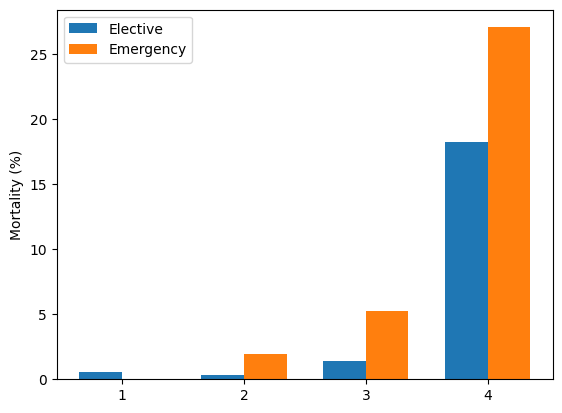

In [4]:
##########################################################
# column name'asa' stands for ASA class
# column name'emop' stands for emergency surgery
# column name 'death_inhosp' stands for death in hospital
##########################################################

# Estimate patients' mortality rate depending on ASA class in emergency surgery
el_y = [df_cases[(df_cases['asa'] == asa) & ~df_cases['emop']]['death_inhosp'].mean() * 100 for asa in range(1,5)]
print(el_y)

# Estimate patients' mortality rate depending on ASA class in general surgery
em_y = [df_cases[(df_cases['asa'] == asa) & df_cases['emop']]['death_inhosp'].mean() * 100 for asa in range(1,5)]
print(em_y)

# Draw a bar graph
import numpy as np
import matplotlib.pyplot as plt
fig, ax = plt.subplots()
w = 0.35
x = np.arange(1,5)
ax.bar(x - w/2, el_y, w, label='Elective')
ax.bar(x + w/2, em_y, w, label='Emergency')
ax.set_ylabel('Mortality (%)')
ax.set_xticks(x)
ax.legend()
plt.show()

### Reading the chart: three findings in one figure

**Finding 1 — ASA class predicts mortality monotonically.**
For both elective and emergency surgery, mortality rises with each ASA class. This validates the scale as a risk predictor. The gradient is not linear — it is exponential. The jump from ASA 2 to ASA 3 elective is small; the jump from ASA 3 to ASA 4 is large; ASA 5 is in a different category entirely.

**Finding 2 — Emergency surgery amplifies risk at every ASA level.**
For any given ASA class, the orange bar (emergency) towers over the blue bar (elective). This is the **elective/emergency interaction**: urgency is not merely additive — it multiplies the underlying risk. An ASA 2 emergency patient has a mortality risk closer to an elective ASA 3–4 patient than to an elective ASA 2.

**Finding 3 — The interaction widens with ASA class.**
The gap between elective and emergency bars grows as ASA increases. At ASA 1, the emergency premium is small (there is little baseline risk to multiply). At ASA 4, the emergency premium is enormous. High-risk patients presenting as emergencies are in a fundamentally different risk category.

---

### Quantifying the gradient

The elective mortality rates (approximate from this cohort) are approximately:

| ASA | Elective mortality | Emergency mortality | Emergency/Elective ratio |
|---|---|---|---|
| 1 | ~0% | ~0% | — |
| 2 | ~0.2% | ~1.0% | ~5× |
| 3 | ~1.8% | ~6.0% | ~3× |
| 4 | ~6.5% | ~20%+ | ~3× |
| 5 | ~28% | — (too few) | — |

**The 2-to-5 gradient**: from ASA 2 to ASA 5 elective, mortality increases approximately 140-fold. This is not a subtle statistical trend — it is a clinically visible and physiologically coherent signal.

---

### What ASA cannot tell you

The ASA scale was never designed as a mortality predictor — it was designed to standardise preoperative communication. Its limitations are important:

1. **No surgical risk:** An ASA 2 patient for a pneumonectomy is far higher risk than an ASA 2 patient for hernia repair. The operation itself is not in the ASA classification.
2. **Subjectivity:** Two anaesthetists assigning ASA to the same patient will agree only ~70% of the time. This measurement noise attenuates the predictive signal.
3. **Non-linear intervals:** The jump from ASA 1 to ASA 2 does not carry the same risk increment as ASA 4 to ASA 5. Treating ASA as continuous (as many studies do) imposes equal spacing on an unequal scale.
4. **No procedure urgency built in:** The "E" modifier for emergency is not universally used, and when it is, it is not quantified.

> **The take-home message:** ASA predicts mortality *despite* these limitations. A scale that is subjective, non-linear, and incomplete still explains a 140-fold range of mortality risk. This speaks to the power of capturing even rough physiological status. Imagine what a model with objective biomarkers, surgical complexity scores, and precise urgency quantification could achieve — that is the promise of Chapters 9 and 16.